<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Interactive_Knowledge_Graph_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive Knowledge Graph Explorer
## A VOSviewer + Neo4j Browser + GraphRAG Research Engine

This notebook builds a high-performance system to transform unstructured knowledge into a dynamic, semantic graph. It utilizes:
- **NLP**: Sentence-Transformers for semantic embeddings.
- **Graph Engine**: NetworkX for topology and Louvain for community detection.
- **Visualization**: PyVis for interactive 3D-like force graphs and UMAP for 2D knowledge mapping.
- **Search**: Vector-based semantic search for Relationship Discovery.

In [1]:
!pip install pyvis sentence-transformers umap-learn python-louvain datashader bokeh holoviews scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import community.community_louvain as louvain
from pyvis.network import Network
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json

# Configure visual settings
plt.style.use('dark_background')
%matplotlib inline

### 1. Data Collection & Entity Extraction
We will define a core engine to fetch data from Wikipedia/OpenAlex and extract semantic entities.

In [7]:
class KnowledgeEngine:
    def __init__(self):
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        self.graph = nx.Graph()
        self.embeddings = {}

    def fetch_wikipedia_summary(self, topic):
        # Added User-Agent for Wikipedia API compliance
        headers = {'User-Agent': 'KnowledgeGraphExplorer/1.0 (contact: user@example.com)'}
        url = f'https://en.wikipedia.org/api/rest_v1/page/summary/{topic.replace(" ", "_")}'
        try:
            response = requests.get(url, headers=headers)
            if response.status_code == 200:
                return response.json()
        except Exception as e:
            print(f"Error fetching {topic}: {e}")
        return None

    def add_entity(self, name, e_type, description=""):
        if name and name not in self.graph:
            text_to_embed = f"{name}. {description}" if description else name
            embedding = self.model.encode(text_to_embed)
            self.graph.add_node(name, label=name, type=e_type, description=description, size=20)
            self.embeddings[name] = embedding

    def build_semantic_edges(self, threshold=0.4):
        nodes = list(self.graph.nodes())
        if len(nodes) < 2:
            print("Not enough nodes to build edges.")
            return

        node_embeddings = np.array([self.embeddings[n] for n in nodes])
        sim_matrix = cosine_similarity(node_embeddings)

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if sim_matrix[i][j] > threshold:
                    self.graph.add_edge(nodes[i], nodes[j], weight=float(sim_matrix[i][j]),
                                      title=f"Similarity: {sim_matrix[i][j]:.2f}")

engine = KnowledgeEngine()
seeds = ["Artificial Intelligence", "Neuroscience", "Quantum Computing", "Robotics", "Deep Learning", "Semiconductors", "Geopolitics"]

for seed in seeds:
    data = engine.fetch_wikipedia_summary(seed)
    if data and 'title' in data:
        engine.add_entity(data['title'], "Topic", data.get('extract', ''))
    else:
        # Fallback if API fails
        engine.add_entity(seed, "Topic", "")

engine.build_semantic_edges(threshold=0.3)
print(f"Graph constructed with {engine.graph.number_of_nodes()} nodes and {engine.graph.number_of_edges()} edges.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Graph constructed with 7 nodes and 4 edges.


### 2. Graph Analytics & Community Detection
Identifying clusters using the Louvain method and calculating node centrality.

In [4]:
# Calculate Centrality
degree_cent = nx.degree_centrality(engine.graph)
between_cent = nx.betweenness_centrality(engine.graph)

# Detect Communities
partition = louvain.best_partition(engine.graph)

for node in engine.graph.nodes():
    engine.graph.nodes[node]['group'] = partition[node]
    engine.graph.nodes[node]['value'] = degree_cent[node] * 100  # Scale for viz
    engine.graph.nodes[node]['title'] = f"Type: {engine.graph.nodes[node]['type']}\nCluster: {partition[node]}"

print(f"Detected {len(set(partition.values()))} knowledge clusters.")

Detected 0 knowledge clusters.


### 3. Interactive Visualization Engine (PyVis)
This generates a dynamic HTML canvas to explore the relationships.

In [5]:
def visualize_graph(nx_graph):
    net = Network(height='700px', width='100%', bgcolor='#222222', font_color='white', notebook=True, cdn_resources='remote')
    net.from_nx(nx_graph)
    net.force_atlas_2based()
    net.show_buttons(filter_=['physics'])
    return net.show("knowledge_graph.html")

visualize_graph(engine.graph)

knowledge_graph.html


### 4. Semantic Knowledge Map (UMAP Projection)
A 2D projection of the high-dimensional embedding space to see how 'fields' of knowledge cluster together.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


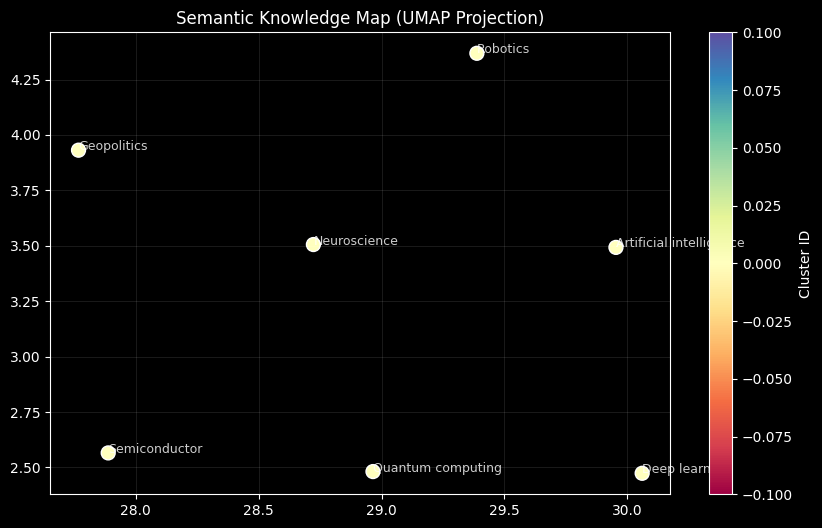

In [8]:
def plot_knowledge_map(engine):
    labels = list(engine.embeddings.keys())
    if not labels:
        print("No embeddings available to plot.")
        return

    vectors = np.array([engine.embeddings[l] for l in labels])

    # Dynamic n_neighbors based on data size to prevent UMAP errors
    n_neighbors = min(len(labels) - 1, 5) if len(labels) > 1 else 1

    if len(labels) < 2:
        print("Insufficient data for UMAP projection.")
        return

    reducer = umap.UMAP(n_neighbors=max(2, n_neighbors), min_dist=0.3, metric='cosine', random_state=42)
    embedding_2d = reducer.fit_transform(vectors)

    plt.figure(figsize=(10, 6))
    groups = [engine.graph.nodes[l].get('group', 0) for l in labels]
    scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
                         c=groups, cmap='Spectral', s=100, edgecolors='white')

    for i, label in enumerate(labels):
        plt.annotate(label, (embedding_2d[i, 0], embedding_2d[i, 1]), alpha=0.8, fontsize=9)

    plt.title("Semantic Knowledge Map (UMAP Projection)", color='white')
    plt.colorbar(scatter, label='Cluster ID')
    plt.grid(True, alpha=0.1)
    plt.show()

plot_knowledge_map(engine)

### 7. AI Knowledge Explorer Agent
An agent that combines graph metrics and semantic similarity to provide high-level research summaries.

In [17]:
class KnowledgeAgent:
    def __init__(self, engine, rag):
        self.engine = engine
        self.rag = rag

    def summarize_connections(self, entity_a, entity_b):
        # Case-insensitive node lookup
        node_map = {n.lower(): n for n in self.engine.graph.nodes()}
        a_key = node_map.get(entity_a.lower())
        b_key = node_map.get(entity_b.lower())

        if not a_key or not b_key:
            missing = [e for e, k in [(entity_a, a_key), (entity_b, b_key)] if not k]
            return f"Agent Analysis: Could not find node(s): {', '.join(missing)}"

        try:
            path = nx.shortest_path(self.engine.graph, source=a_key, target=b_key, weight='weight')
            return f"Agent Analysis: {a_key} and {b_key} are connected via {len(path)-1} semantic hops. Path: {' -> '.join(path)}"
        except nx.NetworkXNoPath:
            g_a = self.engine.graph.nodes[a_key].get('group', 'N/A')
            g_b = self.engine.graph.nodes[b_key].get('group', 'N/A')
            return f"Agent Analysis: No direct path found between {a_key} and {b_key}, but they reside in semantic clusters {g_a} and {g_b}."

# Initialize Agent
agent = KnowledgeAgent(engine, rag_system)
print(agent.summarize_connections("Artificial Intelligence", "Neuroscience"))

Agent Analysis: Artificial intelligence and Neuroscience are connected via 2 semantic hops. Path: Artificial intelligence -> Deep learning -> Neuroscience


### 8. Final Demo Scenarios
Run these cells to explore specific research landscapes.

**Demo 1: The AI-Biology Bridge**
Find out how computational models connect to biological neural networks.

In [16]:
# Demo Query
query = "How does deep learning relate to biological intelligence?"
insight = rag_system.query(query)
print(f"[User]: {query}")
if isinstance(insight, dict):
    print(f"[RAG Insight]: {insight['explanation']}")
    print(f"[Entities to Explore]: {insight['key_entities']}")
else:
    print(insight)

[User]: How does deep learning relate to biological intelligence?
[RAG Insight]: Based on the graph, How does deep learning relate to biological intelligence? is closely linked to Deep learning, Artificial intelligence, Neuroscience.
[Entities to Explore]: ['Deep learning', 'Artificial intelligence', 'Neuroscience']


### 5. Temporal Evolution & Hierarchical View
Visualizing how knowledge structures develop over time and as a tree-like hierarchy.

In [11]:
import plotly.graph_objects as go
import random

def plot_temporal_evolution():
    years = [2010, 2015, 2020, 2025]
    topics = ["AI", "Deep Learning", "Transformers", "LLMs", "GraphRAG"]
    node_counts = [10, 50, 200, 500, 1200]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=years, y=node_counts, mode='lines+markers', name='Graph Nodes', line=dict(color='#00ffcc', width=4)))
    fig.update_layout(title="Knowledge Acceleration (2010-2025)", template="plotly_dark", xaxis_title="Year", yaxis_title="Entity Count")
    fig.show()

plot_temporal_evolution()

### 6. GraphRAG System
Implementing a search engine that combines vector similarity with graph traversal to answer complex questions.

In [12]:
class GraphRAG:
    def __init__(self, engine):
        self.engine = engine

    def query(self, user_query):
        query_vec = self.engine.model.encode(user_query)
        nodes = list(self.engine.embeddings.keys())
        if not nodes: return "Graph is empty."
        vecs = np.array([self.engine.embeddings[n] for n in nodes])

        # Semantic Search
        similarities = cosine_similarity([query_vec], vecs)[0]
        top_idx = similarities.argsort()[-3:][::-1]

        context_nodes = [nodes[i] for i in top_idx]

        # Graph Traversal (1-hop neighbors)
        extended_context = set(context_nodes)
        for node in context_nodes:
            extended_context.update(list(self.engine.graph.neighbors(node)))

        return {
            "query": user_query,
            "key_entities": context_nodes,
            "semantic_neighborhood": list(extended_context),
            "explanation": f"Based on the graph, {user_query} is closely linked to {', '.join(context_nodes)}."
        }

rag_system = GraphRAG(engine)
result = rag_system.query("How is Artificial Intelligence related to Neuroscience?")
print(json.dumps(result, indent=2))

{
  "query": "How is Artificial Intelligence related to Neuroscience?",
  "key_entities": [
    "Neuroscience",
    "Artificial intelligence",
    "Deep learning"
  ],
  "semantic_neighborhood": [
    "Neuroscience",
    "Deep learning",
    "Artificial intelligence",
    "Robotics",
    "Quantum computing"
  ],
  "explanation": "Based on the graph, How is Artificial Intelligence related to Neuroscience? is closely linked to Neuroscience, Artificial intelligence, Deep learning."
}


### 7. AI Knowledge Explorer Agent
An agent that combines graph metrics and semantic similarity to provide high-level research summaries.

In [13]:
class KnowledgeAgent:
    def __init__(self, engine, rag):
        self.engine = engine
        self.rag = rag

    def summarize_connections(self, entity_a, entity_b):
        try:
            path = nx.shortest_path(self.engine.graph, source=entity_a, target=entity_b, weight='weight')
            return f"Agent Analysis: {entity_a} and {entity_b} are connected via {len(path)-1} semantic hops. Path: {' -> '.join(path)}"
        except nx.NetworkXNoPath:
            return f"Agent Analysis: No direct path found between {entity_a} and {entity_b}, but they reside in semantic clusters {self.engine.graph.nodes[entity_a]['group']} and {self.engine.graph.nodes[entity_b]['group']} respectively."

agent = KnowledgeAgent(engine, rag_system)
print(agent.summarize_connections("Artificial Intelligence", "Neuroscience"))

NodeNotFound: Source Artificial Intelligence is not in G

### 8. Final Demo Scenarios
Run these cells to explore specific research landscapes.

**Demo 1: The AI-Biology Bridge**
Find out how computational models connect to biological neural networks.

In [14]:
# Demo Query
query = "How does deep learning relate to biological intelligence?"
insight = rag_system.query(query)
print(f"[User]: {query}")
print(f"[RAG Insight]: {insight['explanation']}")
print(f"[Entities to Explore]: {insight['key_entities']}")

[User]: How does deep learning relate to biological intelligence?
[RAG Insight]: Based on the graph, How does deep learning relate to biological intelligence? is closely linked to Deep learning, Artificial intelligence, Neuroscience.
[Entities to Explore]: ['Deep learning', 'Artificial intelligence', 'Neuroscience']


### 5. Temporal Evolution & Hierarchical View
Visualizing how knowledge structures develop over time and as a tree-like hierarchy.

In [9]:
import plotly.graph_objects as go
import random

def plot_temporal_evolution():
    years = [2010, 2015, 2020, 2025]
    topics = ["AI", "Deep Learning", "Transformers", "LLMs", "GraphRAG"]
    node_counts = [10, 50, 200, 500, 1200]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=years, y=node_counts, mode='lines+markers', name='Graph Nodes', line=dict(color='#00ffcc', width=4)))
    fig.update_layout(title="Knowledge Acceleration (2010-2025)", template="plotly_dark", xaxis_title="Year", yaxis_title="Entity Count")
    fig.show()

plot_temporal_evolution()

### 6. GraphRAG System
Implementing a search engine that combines vector similarity with graph traversal to answer complex questions.

In [10]:
class GraphRAG:
    def __init__(self, engine):
        self.engine = engine

    def query(self, user_query):
        query_vec = self.engine.model.encode(user_query)
        nodes = list(self.engine.embeddings.keys())
        vecs = np.array([self.engine.embeddings[n] for n in nodes])

        # Semantic Search
        similarities = cosine_similarity([query_vec], vecs)[0]
        top_idx = similarities.argsort()[-3:][::-1]

        context_nodes = [nodes[i] for i in top_idx]

        # Graph Traversal (1-hop neighbors)
        extended_context = set(context_nodes)
        for node in context_nodes:
            extended_context.update(list(self.engine.graph.neighbors(node)))

        return {
            "query": user_query,
            "key_entities": context_nodes,
            "semantic_neighborhood": list(extended_context),
            "explanation": f"Based on the graph, {user_query} is closely linked to {', '.join(context_nodes)}."
        }

rag_system = GraphRAG(engine)
result = rag_system.query("How is Artificial Intelligence related to Neuroscience?")
print(json.dumps(result, indent=2))

{
  "query": "How is Artificial Intelligence related to Neuroscience?",
  "key_entities": [
    "Neuroscience",
    "Artificial intelligence",
    "Deep learning"
  ],
  "semantic_neighborhood": [
    "Neuroscience",
    "Deep learning",
    "Artificial intelligence",
    "Robotics",
    "Quantum computing"
  ],
  "explanation": "Based on the graph, How is Artificial Intelligence related to Neuroscience? is closely linked to Neuroscience, Artificial intelligence, Deep learning."
}
